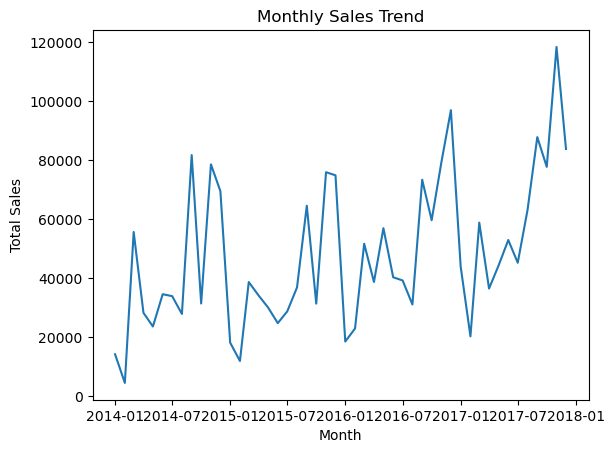

Baseline MAE: 21652.239451063826
Linear Regression MAE: 17646.25172777226


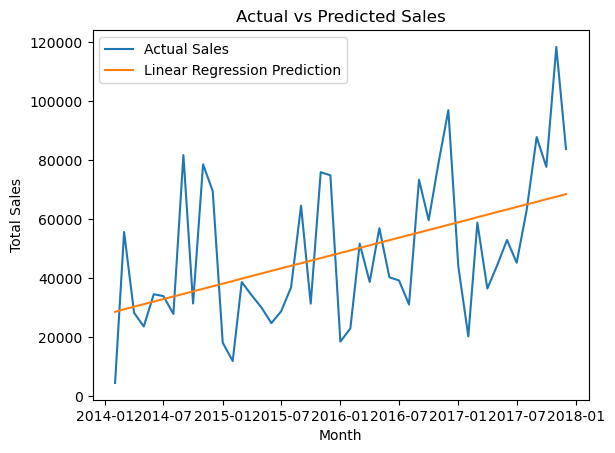

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Load data
df = pd.read_csv(r"D:\tableau\monthly_sales.csv")

# Convert month to datetime and sort
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month')

# Plot monthly sales trend
plt.figure()
plt.plot(df['month'], df['total_sales'])
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.show()

# Baseline model (previous month sales)
df['previous_month_sales'] = df['total_sales'].shift(1)
df_baseline = df.dropna()

# Baseline MAE
mae_baseline = mean_absolute_error(
    df_baseline['total_sales'],
    df_baseline['previous_month_sales']
)

print("Baseline MAE:", mae_baseline)

# Prepare data for Linear Regression
df_lr = df_baseline.copy()
df_lr['time_index'] = range(len(df_lr))

X = df_lr[['time_index']]
y = df_lr['total_sales']

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
df_lr['lr_prediction'] = model.predict(X)

# Linear Regression MAE
mae_lr = mean_absolute_error(
    df_lr['total_sales'],
    df_lr['lr_prediction']
)

print("Linear Regression MAE:", mae_lr)

# Plot Actual vs Linear Regression prediction
plt.figure()
plt.plot(df_lr['month'], df_lr['total_sales'], label='Actual Sales')
plt.plot(df_lr['month'], df_lr['lr_prediction'], label='Linear Regression Prediction')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()
